# Multi-Run BO vs. Random Search Analysis

This notebook compares the combined outputs produced by `multi_run_bo.py` and `multi_run_random_search.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

RESULTS_DIR = Path("multi_run_results")
TRIAL_FILES = {
    "bo": RESULTS_DIR / "bo_all_trials.csv",
    "random_search": RESULTS_DIR / "random_search_all_trials.csv",
}
SUMMARY_FILE = RESULTS_DIR / "summary.csv"

In [2]:
def load_trials() -> pd.DataFrame:
    existing = {method: path for method, path in TRIAL_FILES.items() if path.exists()}
    missing = {method: path for method, path in TRIAL_FILES.items() if not path.exists()}

    if not existing:
        missing_text = "\n".join(f"- {path}" for path in missing.values())
        raise FileNotFoundError(
            "No combined trial CSVs found. Run these first from the BO folder:\n"
            "  python multi_run_bo.py\n"
            "  python multi_run_random_search.py\n\n"
            f"Missing files:\n{missing_text}"
        )

    if missing:
        print("Partial results loaded. Missing files:")
        for path in missing.values():
            print(f"- {path}")

    frames = []
    for method, path in existing.items():
        df = pd.read_csv(path)
        if "method" not in df.columns:
            df["method"] = method
        frames.append(df)

    trials = pd.concat(frames, ignore_index=True, sort=False)
    required = {"method", "run_index", "trial_index", "objective_mean", "best_objective_so_far"}
    missing_columns = sorted(required - set(trials.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns in trial results: {missing_columns}")

    trials["method"] = trials["method"].replace({"bo": "BO", "random_search": "Random Search"})
    return trials.sort_values(["method", "run_index", "trial_index"]).reset_index(drop=True)


trials = load_trials()
display(trials.head())
print(f"Loaded {len(trials)} trial rows from {trials['run_index'].nunique()} run indices.")

,method,run_index,trial_index,preparation_capacity,sorting_capacity,analysis1_capacity,analysis2_capacity,evaluation_capacity,dispatching_capacity,worker_capacity,...,worker_capacity_norm_mean,time_in_system_mean_norm_mean,time_in_system_std_norm_mean,objective_completed_contribution_mean,objective_late_contribution_mean,objective_station_capacity_contribution_mean,objective_worker_capacity_contribution_mean,objective_time_mean_contribution_mean,objective_time_std_contribution_mean,best_objective_so_far
0,BO,0,0,3,2,4,1,1,1,5,...,0.444444,0.766155,0.411921,-0.626365,1.744381,0.200000,0.155556,0.306462,0.0,1.780034
1,BO,0,1,4,4,2,3,5,4,9,...,0.888889,0.563673,0.297780,-0.726494,1.100144,0.533333,0.311111,0.225469,0.0,1.443564
2,BO,0,2,3,3,4,3,3,5,1,...,0.000000,1.402402,0.768668,-0.254713,2.743622,0.500000,0.000000,0.560961,0.0,1.443564
3,BO,0,3,1,3,1,5,3,3,6,...,0.555556,1.295841,0.719023,-0.368623,2.579841,0.333333,0.194444,0.518336,0.0,1.443564
4,BO,0,4,1,2,2,5,2,1,2,...,0.111111,0.824883,0.446517,-0.475858,2.178023,0.233333,0.038889,0.329953,0.0,1.443564


Loaded 1200 trial rows from 20 run indices.


## Best Objective So Far Per Run

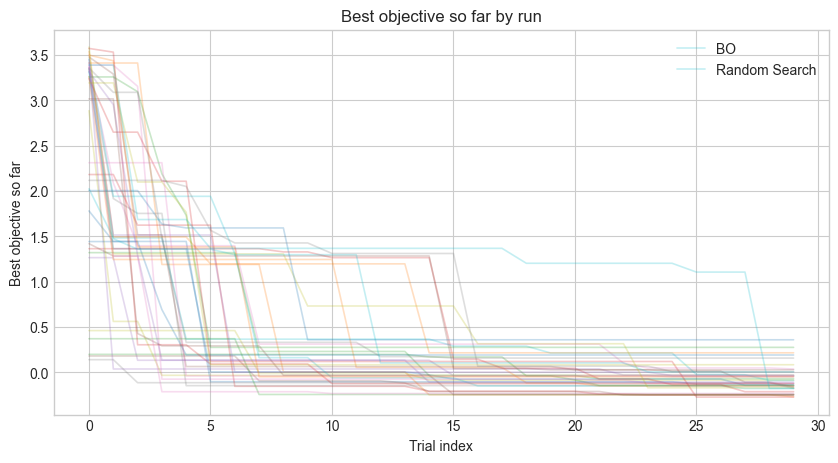

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

for (method, run_index), run_df in trials.groupby(["method", "run_index"]):
    ax.plot(
        run_df["trial_index"],
        run_df["best_objective_so_far"],
        alpha=0.25,
        linewidth=1.2,
        label=method,
    )

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys())
ax.set_title("Best objective so far by run")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()

## Median With IQR Band

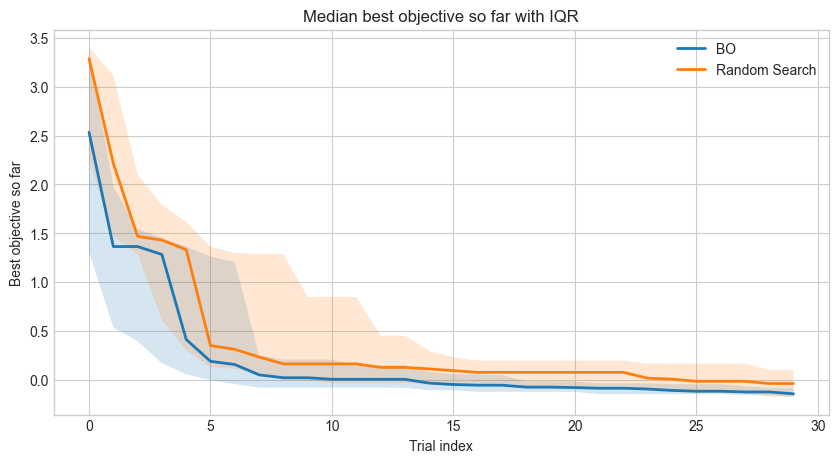

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for method, method_df in trials.groupby("method"):
    grouped = method_df.groupby("trial_index")["best_objective_so_far"]
    stats = grouped.quantile([0.25, 0.5, 0.75]).unstack()
    stats.columns = ["q25", "median", "q75"]
    ax.plot(stats.index, stats["median"], linewidth=2.0, label=method)
    ax.fill_between(stats.index, stats["q25"], stats["q75"], alpha=0.18)

ax.legend()
ax.set_title("Median best objective so far with IQR")
ax.set_xlabel("Trial index")
ax.set_ylabel("Best objective so far")
plt.show()

## Final Best Objective Per Run

C:\Users\fabia\AppData\Local\Temp\ipykernel_19948\711475105.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showmeans=True)


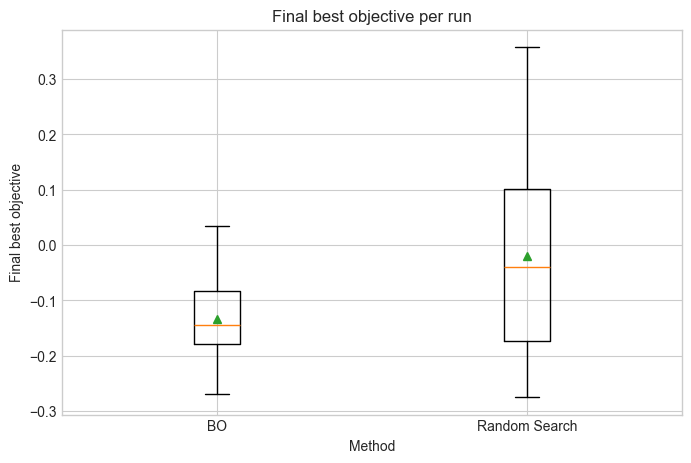

,method,run_index,final_best_objective
29,BO,0,-0.130711
59,BO,1,-0.269970
89,BO,2,-0.072062
119,BO,3,-0.249567
149,BO,4,-0.048873
179,BO,5,-0.253176
209,BO,6,0.034960
239,BO,7,-0.148483
269,BO,8,-0.087663
299,BO,9,-0.179618


In [5]:
final_trials = (
    trials.sort_values(["method", "run_index", "trial_index"])
    .groupby(["method", "run_index"], as_index=False)
    .tail(1)
    .copy()
)
final_trials["final_best_objective"] = final_trials["best_objective_so_far"]

methods = list(final_trials["method"].drop_duplicates())
data = [
    final_trials.loc[final_trials["method"] == method, "final_best_objective"].dropna()
    for method in methods
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=methods, showmeans=True)
ax.set_title("Final best objective per run")
ax.set_xlabel("Method")
ax.set_ylabel("Final best objective")
plt.show()

display(final_trials[["method", "run_index", "final_best_objective"]].sort_values(["method", "run_index"]))

## Optional Final KPI Comparison

method,BO,Random Search
n_orders_completed_mean,948.333333,347.083333
n_orders_late_mean,0.000000,195.833333
n_orders_incomplete_mean,50.216667,649.483333
late_total_norm_mean,0.050884,0.868058
time_in_system_mean_mean,23.580238,320.841856
wip_time_in_system_mean_mean,36.832854,465.866005


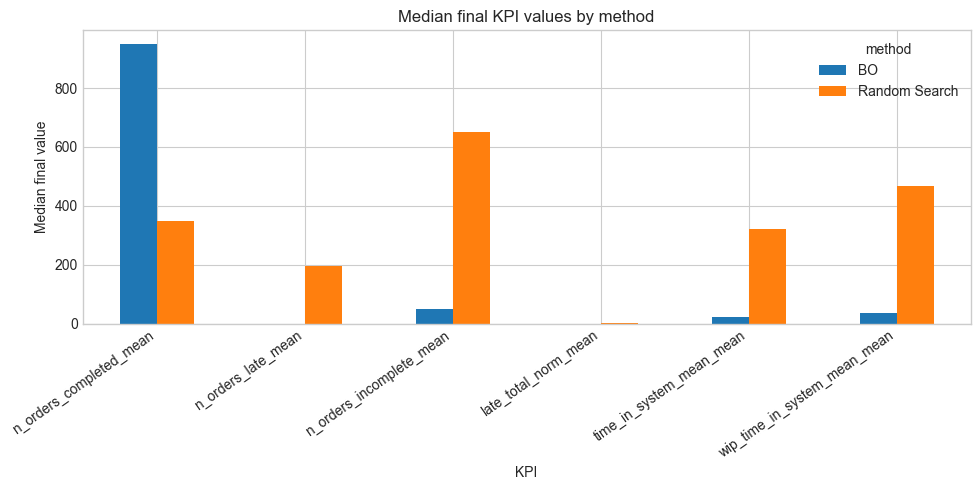

In [6]:
candidate_kpis = [
    "n_orders_completed_mean",
    "n_orders_late_mean",
    "n_orders_incomplete_mean",
    "late_total_norm_mean",
    "time_in_system_mean_mean",
    "wip_time_in_system_mean_mean",
]
available_kpis = [column for column in candidate_kpis if column in final_trials.columns]

if not available_kpis:
    print("No optional final KPI columns found in the combined trial results.")
else:
    kpi_summary = final_trials.groupby("method")[available_kpis].median().T
    display(kpi_summary)
    ax = kpi_summary.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Median final KPI values by method")
    ax.set_xlabel("KPI")
    ax.set_ylabel("Median final value")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()